## Testing the Gadget for the J1-J2 model

### Imports

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from src.interaction_utils import EffectiveInteractionOptimizer,EffectiveInteractionOptimizerTunableSelfEnergy
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import qutip as qt
from src.utils import computational_basis
from qutip import fidelity
from NSMFermions.hamiltonian_utils import FermiHubbardHamiltonian
from NSMFermions.nuclear_physics_utils import get_twobody_nuclearshell_model,SingleParticleState
import numpy as np
import torch
from typing import Dict
import scipy
from NSMFermions.qml_models import AdaptVQEFermiHubbard
from NSMFermions.qml_utils.train import Fit
from NSMFermions.qml_utils.utils import configuration
from scipy.sparse.linalg import eigsh,expm_multiply
from tqdm import trange
import matplotlib.pyplot as plt
from NSMFermions.utils_quasiparticle_approximation import QuasiParticlesConverter,HardcoreBosonsBasis,QuasiParticlesConverterOnlynnpp
from src.utils import generate_particleconservation_basis,array_to_qutip, build_total_hamiltonian, build_effective_hamiltonian,compute_particle_number

/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


### Load the coupling of the Quasiparticle Hamiltonian

We upload the $g^{(1)}_{AB}$ couplings from the numpy dictionary, we also fix the number of Qubit for the system that we are considering. Since the $^{6}\text{Be}$ involves only one active quasiparticle proton, we don't need any two-body interaction

g_matrix:
 [[0.  0.2 0.  0.  0. ]
 [0.2 0.  1.  0.  0. ]
 [0.  1.  0.  0.2 0. ]
 [0.  0.  0.2 0.  1. ]
 [0.  0.  0.  1.  0. ]]
diagonal_elements: [-1. -1. -1. -1. -1.]


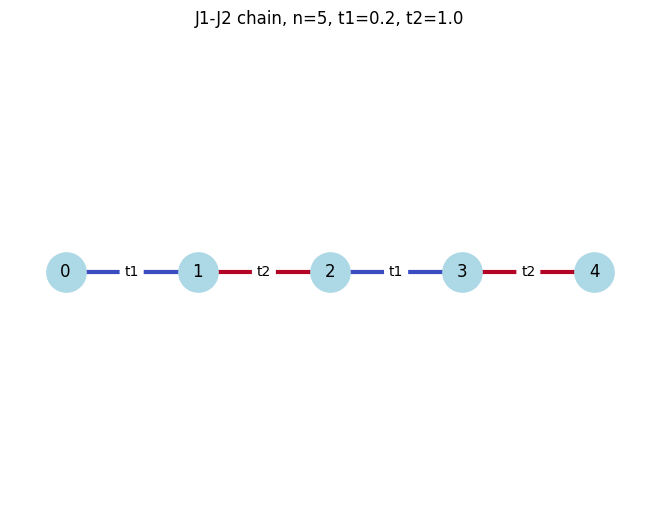

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# --- parameters ---
n_qubits = 5
t1 = 0.2
t2 = 1.

# --- build J1-J2 chain ---
G = nx.Graph()
G.add_nodes_from(range(n_qubits))

# alternating couplings: t1, t2, t1, t2, ...
for i in range(n_qubits - 1):
    t = t1 if i % 2 == 0 else t2
    G.add_edge(i, i+1, weight=t)

node_to_idx = {i: i for i in range(n_qubits)}

# --- build g_matrix ---
g_matrix = np.zeros((n_qubits, n_qubits))
for u, v, data in G.edges(data=True):
    g_matrix[u, v] = data['weight']
    g_matrix[v, u] = data['weight']

# --- diagonal elements ---
diagonal_elements = -1*np.ones(n_qubits)

# --- g_onebody dictionary ---
g_onebody = {}
for i in range(n_qubits):
    for j in range(n_qubits):
        g_onebody[(i, j)] = diagonal_elements[i] if i == j else g_matrix[i, j]

print("g_matrix:\n", g_matrix)
print("diagonal_elements:", diagonal_elements)

# --- visualize ---
pos = {i: (i, 0) for i in range(n_qubits)}
edge_colors = [G[u][v]['weight'] for u, v in G.edges()]
edge_labels = {(u, v): f't{"1" if G[u][v]["weight"]==t1 else "2"}'
               for u, v in G.edges()}

nx.draw(G, pos=pos, with_labels=True,
        labels=node_to_idx,
        edge_color=edge_colors,
        edge_cmap=plt.cm.coolwarm,
        width=3, node_color='lightblue', node_size=800)
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels)
plt.title(f"J1-J2 chain, n={n_qubits}, t1={t1}, t2={t2}")
plt.show()

basis=computational_basis(n_qubits)

#### Study the Quasiparticle Hamiltonian with the Hardcore Boson Basis

In [28]:
nparticles_a=1
nparticles_b=0

particle_conserved_basis=generate_particleconservation_basis(size_a=n_qubits,size_b=0,nparticles_a=nparticles_a,nparticles_b=nparticles_b)

print(particle_conserved_basis)

# initialize the class in the number sector of the quasiparticle space (see NSMFermion library)
HBB=HardcoreBosonsBasis(basis=particle_conserved_basis)
tightbinding_hamiltonian_particle_conserved=0.
for key,value in g_onebody.items():
    idx_a,idx_b=key
    if idx_a!=idx_b:
        tightbinding_hamiltonian_particle_conserved-=value*HBB.adag_a_matrix(idx_a,idx_b)
    else:
         tightbinding_hamiltonian_particle_conserved+=value*HBB.adag_a_matrix(idx_a,idx_b)

print(tightbinding_hamiltonian_particle_conserved)
value,eigenstates_particle_conserved=np.linalg.eigh(tightbinding_hamiltonian_particle_conserved.todense())

print(value)
    

[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]]
<List of Lists sparse matrix of dtype 'float64'
	with 13 stored elements and shape (5, 5)>
  Coords	Values
  (0, 0)	-1.0
  (0, 1)	-0.2
  (1, 0)	-0.2
  (1, 1)	-1.0
  (1, 2)	-1.0
  (2, 1)	-1.0
  (2, 2)	-1.0
  (2, 3)	-0.2
  (3, 2)	-0.2
  (3, 3)	-1.0
  (3, 4)	-1.0
  (4, 3)	-1.0
  (4, 4)	-1.0
[-2.11355287 -1.91651514 -1.         -0.08348486  0.11355287]


#### Check the localization of the eigenstates

-1.0000000000000002
(5, 5)


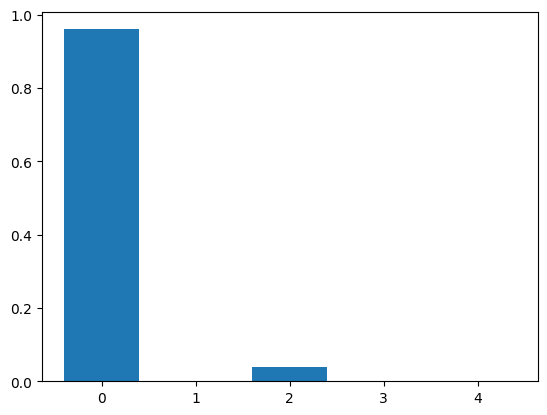

In [29]:
idx_state=2
print(value[idx_state])
eigenstates_particle_conserved_numpy = np.asarray(eigenstates_particle_conserved)
print(eigenstates_particle_conserved.shape)
prob_state=eigenstates_particle_conserved_numpy[:,idx_state].conj()*eigenstates_particle_conserved_numpy[:,idx_state]

plt.bar(np.arange(prob_state.shape[0]),prob_state)
plt.show()

#### Write the Single Particle Tight Binding Hamiltonian

In [30]:
hamiltonian_xy=0.
for i in range(n_qubits):
    for j in range(i+1,n_qubits):
        hamiltonian_xy+=SpinOperator([('x',i,'x',j)],coupling=[-0.5*g_matrix[i,j]],size=n_qubits,verbose=1).qutip_op
        hamiltonian_xy+=SpinOperator([('y',i,'y',j)],coupling=[-0.5*g_matrix[i,j]],size=n_qubits,verbose=1).qutip_op
hamiltonian_z=0.
for i in range(n_qubits):
    hamiltonian_z+=SpinOperator([('qz',i)],coupling=[diagonal_elements[i]],size=n_qubits,verbose=1).qutip_op
tightbinding_hamiltonian=hamiltonian_z+hamiltonian_xy

In [53]:

eigenvalues_tb, eigenstates_tb = tightbinding_hamiltonian.eigenstates()

print(eigenvalues_tb)

for r,eigenstate in enumerate(eigenstates_tb):

    psi=eigenstate.full().flatten()
    n_value=compute_particle_number(psi,basis)

    if np.abs(n_value-1)<10**-2:
        print(eigenvalues_tb[r])
        print(r,'\n')

[-5.11355287 -5.03006801 -5.         -4.91651514 -4.11355287 -4.03006801
 -4.         -3.91651514 -3.19703773 -3.11355287 -3.08348486 -3.
 -3.         -2.91651514 -2.88644713 -2.80296227 -2.19703773 -2.11355287
 -2.08348486 -2.         -2.         -1.91651514 -1.88644713 -1.80296227
 -1.08348486 -1.         -0.96993199 -0.88644713 -0.08348486  0.
  0.03006801  0.11355287]
-2.113552872566002
17 

-1.9165151389911659
21 

-0.9999999999999998
25 

-0.0834848610088317
28 

0.11355287256600437
31 



##### Test the dynamics of the Edge state

In [59]:
psi=np.zeros(basis.shape[0])
psi[2**(n_qubits-1)]=1 # initialize at [1,0,0,0,0]
print(basis[2**(n_qubits-1)])
psi_init=psi.copy()
print('AAA',np.linalg.norm(psi_init.dot(eigenstates_tb[25].full().flatten()))**2)
tightbinding_hamiltonian_scipy=tightbinding_hamiltonian.data.as_scipy()
print('energy initial state=',psi_init.dot(tightbinding_hamiltonian_scipy.dot(psi_init)))

time=np.linspace(0,10,50)
delta_t=time[1]-time[0]
fidelity_loc=[]
particle_conservation=[]
for i,t in enumerate(time):
    psi=expm_multiply(-1j*delta_t*tightbinding_hamiltonian_scipy,psi)
    fidelity_loc.append(psi.conj().dot(psi_init)*(psi.conj().dot(psi_init)).conj())
    particle_conservation.append(compute_particle_number(psi,basis))
print(basis.shape)

[1 0 0 0 0]
AAA 0.9600614439324116
energy initial state= (-1+0j)
(32, 5)


/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


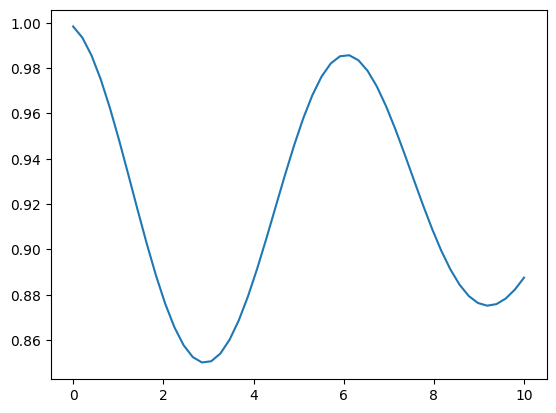

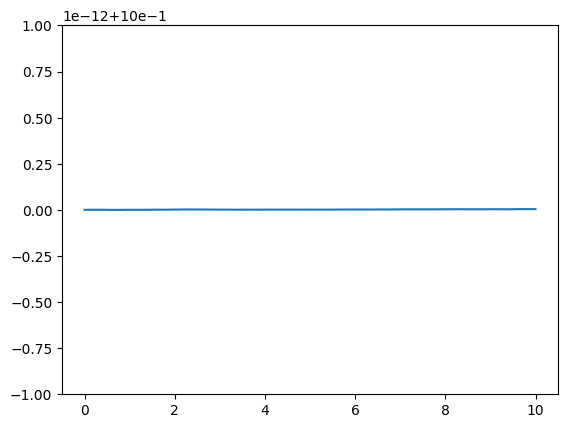

(1.0000000000000033-1.073292477761401e-18j)


In [60]:
plt.plot(time,fidelity_loc)

plt.show()

plt.plot(time,particle_conservation)
plt.show()

n_value=np.einsum('i,ia->',psi.conj()*psi,basis)

print(n_value)

Now, we get the spectrum of this Hamiltonian

### Create the Effective interaction

Here the effective Interaction should be simple. We focus on the costant values of the hopping term and we take the square out of it. In this notebook we work with propagators to change the structure and the amplitude of the edges

In [61]:
d_opt=np.sqrt(t2)*np.ones(n_qubits)

### Write the Diagonal part of the Ising Hamiltonian

Now, we have to write the full ising Hamiltonian that describes the constrain subspace, where our effective Hamiltonian acts, and then see how the spectrum behaves

#### Define the hamiltonian $H_z$ out of the couplings and constrains

In [146]:
# get the total particle constrain 
gamma=100
ntot=1

links=np.zeros(n_qubits)

coupling_dict={}
for i in range(n_qubits):
    for j in range(i+1,n_qubits):
        if j!=i+1:
                coupling_dict[(i,j)]=-1.95
        elif j==i+1:
            if i%2==0:
                print('index i=',i,j)
                # we need to remap in a different direction
                coupling_dict[(i,j)]=-2.66
            else:
                print('discarded=',i)
print(coupling_dict)
total_hamiltonian,_,_=build_total_hamiltonian(n_qubits=n_qubits,d_opt=d_opt,gamma=gamma,links=links,coupling_dict=coupling_dict,ntot=ntot)

for i in range(basis.shape[0]):
    print(basis[i],total_hamiltonian[i,i])
#### then we can compute the self energy to remove it
new_hamiltonian,_,hamiltonian_delta,_,_=build_effective_hamiltonian(total_hamiltonian=total_hamiltonian,basis=basis,gamma=gamma,low_energy_k=1,high_energy_k=[0,2])

print('delta hamiltonian=',hamiltonian_delta*(gamma))


delta_h=np.zeros(diagonal_elements.shape[0])
for i in range(diagonal_elements.shape[0]):
    for j in range(diagonal_elements.shape[0]):
        print(i,j)
        print(new_hamiltonian[i,j]*gamma)
        print(hamiltonian_delta[i,j]*gamma)
        
        print(tightbinding_hamiltonian_particle_conserved[i,j],'\n')
        
        if i==j:
            links[i]=(hamiltonian_delta[-i-1+n_qubits,-j-1+n_qubits]*gamma -1) #the interaction



total_hamiltonian,longitudinal_hamiltonian,_=build_total_hamiltonian(n_qubits=n_qubits,d_opt=d_opt,gamma=gamma,links=links,coupling_dict=coupling_dict,ntot=ntot)

new_hamiltonian,hamiltonian_aa,hamiltonian_delta,_,_=build_effective_hamiltonian(total_hamiltonian=total_hamiltonian,basis=basis,gamma=gamma,low_energy_k=1,high_energy_k=[0,2])

print(new_hamiltonian*gamma)


        

index i= 0 1
discarded= 1
index i= 2 3
discarded= 3
{(0, 1): -2.66, (0, 2): -1.95, (0, 3): -1.95, (0, 4): -1.95, (1, 3): -1.95, (1, 4): -1.95, (2, 3): -2.66, (2, 4): -1.95}
ij 0 1 -2.66
ij 0 2 -1.95
ij 0 3 -1.95
ij 0 4 -1.95
ij 1 3 -1.95
ij 1 4 -1.95
ij 2 3 -2.66
ij 2 4 -1.95
[0 0 0 0 0] (100+0j)
[0 0 0 0 1] 0j
[0 0 0 1 0] 0j
[0 0 0 1 1] (100+0j)
[0 0 1 0 0] 0j
[0 0 1 0 1] (-95+0j)
[0 0 1 1 0] (-166+0j)
[0 0 1 1 1] (-61+0j)
[0 1 0 0 0] 0j
[0 1 0 0 1] (-95+0j)
[0 1 0 1 0] (-95+0j)
[0 1 0 1 1] (10+0j)
[0 1 1 0 0] (100+0j)
[0 1 1 0 1] (10+0j)
[0 1 1 1 0] (-61+0j)
[0 1 1 1 1] (49+0j)
[1 0 0 0 0] 0j
[1 0 0 0 1] (-95+0j)
[1 0 0 1 0] (-95+0j)
[1 0 0 1 1] (10+0j)
[1 0 1 0 0] (-95+0j)
[1 0 1 0 1] (-185+0j)
[1 0 1 1 0] (-256+0j)
[1 0 1 1 1] (-146+0j)
[1 1 0 0 0] (-166+0j)
[1 1 0 0 1] (-256+0j)
[1 1 0 1 0] (-256+0j)
[1 1 0 1 1] (-146+0j)
[1 1 1 0 0] (-61+0j)
[1 1 1 0 1] (-146+0j)
[1 1 1 1 0] (-217+0j)
[1 1 1 1 1] (-102+0j)
H_AA block:
<Compressed Sparse Row sparse matrix of dtype 'complex128'
	wi

/tmp/ipykernel_32979/3205400097.py:40: ComplexWarning: Casting complex values to real discards the imaginary part
  links[i]=(hamiltonian_delta[-i-1+n_qubits,-j-1+n_qubits]*gamma -1) #the interaction


#### Plot a representation of the diagonal part of the Ising Hamiltonian

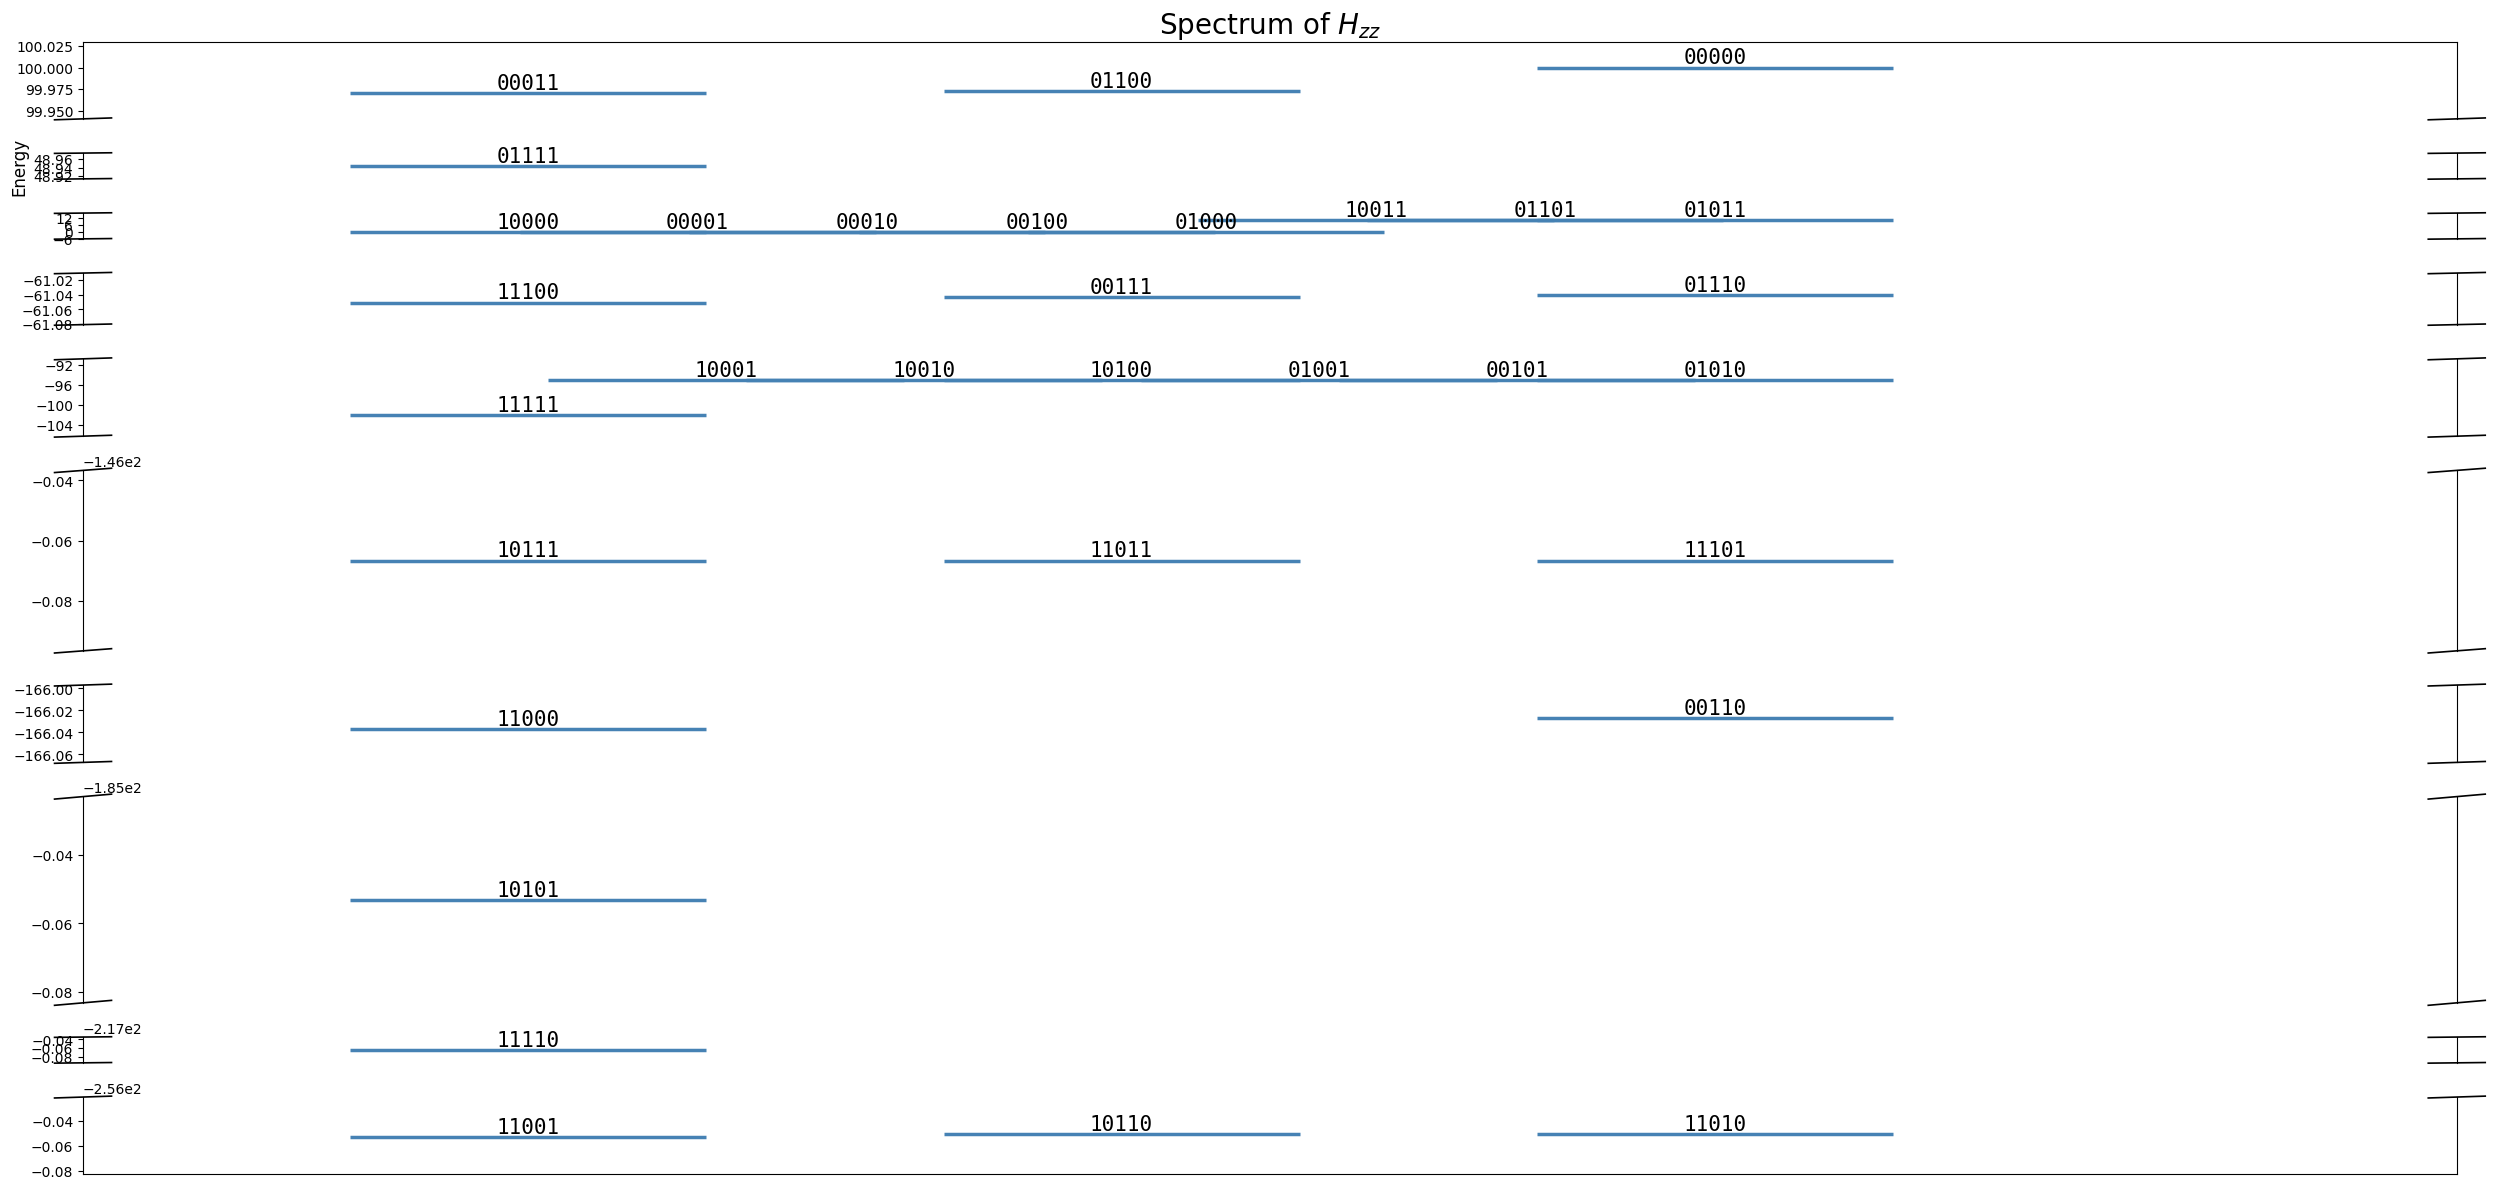

In [147]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

#### this should go to the utils
def plot_spectrum(energies, basis, gap_threshold=0.3, figsize=(25, 12)):
    """
    Plot energy spectrum with broken axis to show both small splittings
    and large gaps between subspaces.

    Parameters
    ----------
    energies : array, shape (N,)
    basis : array, shape (N, n_qubits)
    gap_threshold : float
        Fraction of max gap used to detect subspace boundaries.
    figsize : tuple
    """
    labels = [''.join(map(str, row)) for row in basis]
    order = np.argsort(energies)
    sorted_energies = energies[order]
    sorted_labels = [labels[i] for i in order]

    # --- detect subspaces from large gaps ---
    gaps = np.diff(sorted_energies)
    max_gap = gaps.max()
    boundaries = np.where(gaps > gap_threshold * max_gap)[0]
    splits = np.split(np.arange(len(sorted_energies)), boundaries + 1)

    n_panels = len(splits)
    heights = [max(len(s), 1) for s in splits]

    fig, axes = plt.subplots(n_panels, 1, figsize=figsize,
                             gridspec_kw={'height_ratios': heights},
                             squeeze=False)
    axes = axes.flatten()
    splits = splits[::-1]

    

    for ax, group in zip(axes, splits):

        es = sorted_energies[group]
        ls = [sorted_labels[i] for i in group]
        n = len(es)

        # stagger x positions to avoid label overlap
        x_positions = np.linspace(0.15, 0.55, max(n, 1))

        for x, e, label in zip(x_positions, es, ls):
            ax.hlines(e, x - 0.06, x + 0.06, linewidth=2.5, color='steelblue')
            ax.text(x, e, label, va='bottom', ha='center',
                    fontsize=15, fontfamily='monospace')

        span = es.max() - es.min()
        margin = max(span * 0.6, 0.03)
        ax.set_ylim(es.min() - margin, es.max() + margin)
        ax.set_xlim(0, 0.8)
        ax.set_xticks([])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))

    # --- broken axis styling ---
    for ax in axes[:-1]:
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(bottom=False)
    for ax in axes[1:]:
        ax.spines['top'].set_visible(False)

    # break marks between panels
    d = 0.012
    for ax_bot, ax_top in zip(axes[1:], axes[:-1]):
        for ax, y in [(ax_bot, 1), (ax_top, 0)]:
            kw = dict(color='k', clip_on=False, linewidth=1.2,
                      transform=ax.transAxes)
            ax.plot((-d, +d), (y - d, y + d), **kw)
            ax.plot((1 - d, 1 + d), (y - d, y + d), **kw)

    axes[1].set_ylabel('Energy', fontsize=12)
    axes[0].set_title(r'Spectrum of $H_{zz}$', fontsize=20)

    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    axes[0].yaxis.set_major_formatter(formatter)
    axes[1].yaxis.set_major_formatter(formatter)
    axes[2].yaxis.set_major_formatter(formatter)
    plt.tight_layout()
    plt.show()




plot_spectrum(longitudinal_hamiltonian.diag(), basis)

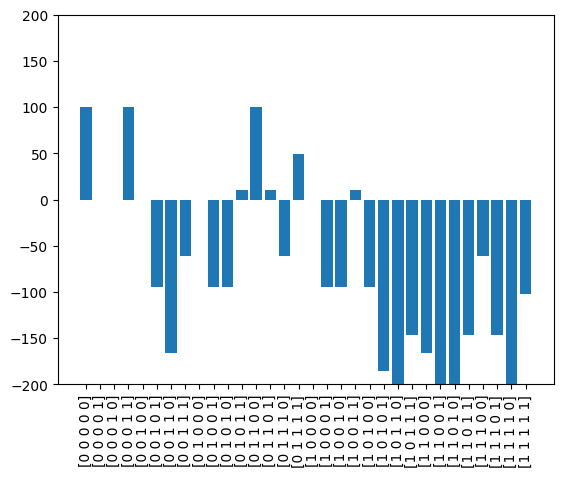

In [148]:
plt.bar(np.arange(basis.shape[0]),longitudinal_hamiltonian.diag())
plt.xticks(np.arange(basis.shape[0]),basis,rotation=90)
plt.ylim([-200,200])
plt.show()

### Part of the second step is to introduce the transverse field term

In [149]:
# the transverse field
transverse_hamiltonian=0.
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    transverse_hamiltonian+=SpinOperator([('x',i)],coupling=[d_opt[i]/np.sqrt(2)],size=n_qubits,verbose=1).qutip_op

#### Compute the spectrum of the full Hamiltonian

Once that we compute the spectrum, we expect that our ground state lies in the subspace near the $E_0=0$ region, Let's see what we get

In [150]:

eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = total_hamiltonian.eigenstates()


#### Check the structure of the effective Hamiltonian to control the longitudinal couplings $g_{AA}$

In [151]:
for r,eigenstate in enumerate(eigenstates_tb):

    psi=eigenstate.full().flatten()
    n_value=compute_particle_number(psi,basis)

    if np.abs(n_value-1)<10**-2:
        print(eigenvalues_tb[r])
print('\n')
for r,eigenstate in enumerate(eigenstates_total_hamiltonian):

    psi=eigenstate.full().flatten()
    n_value=compute_particle_number(psi,basis)
    if np.abs(n_value-1)<10**-1:
        print(eigenvalues_total_hamiltonian[r]*gamma)

-2.113552872566002
-1.9165151389911659
-0.9999999999999998
-0.0834848610088317
0.11355287256600437


-2.069644981150624
-1.961300014083648
-1.0085267943832281
-0.09293099028544055
0.12848609532860217


##### Out-of-Equilibrium Dynamics

In [152]:
psi=np.zeros(basis.shape[0])
psi[2**(n_qubits-1)]=1 # initialize at [1,0,0,0,0]
print(basis[2**(n_qubits-1)])
psi_init=psi.copy()
total_hamiltonian_scipy=total_hamiltonian.data.as_scipy()

time_simulated=np.linspace(0,10*gamma,int(50*gamma))
delta_t=time_simulated[1]-time_simulated[0]
fidelity_simulated=[]
for i,t in enumerate(time_simulated):
    psi=expm_multiply(-1j*delta_t*total_hamiltonian_scipy,psi)
    fidelity_simulated.append(psi.conj().dot(psi_init)*(psi.conj().dot(psi_init)).conj())

[1 0 0 0 0]


/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


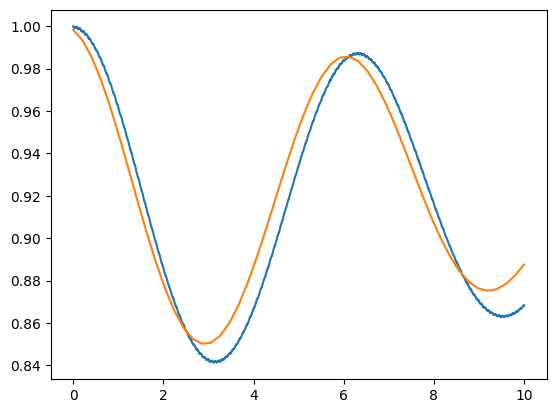

In [153]:
plt.plot(time_simulated/gamma,fidelity_simulated)
plt.plot(time,fidelity_loc)
plt.show()

/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)
/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


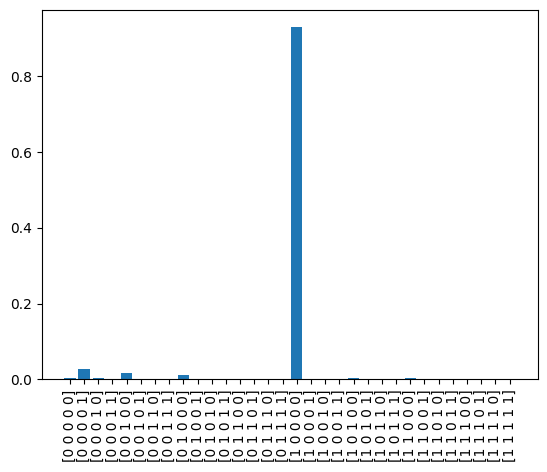

In [128]:
plt.bar(np.arange(basis.shape[0]),psi.conj()*psi)
plt.xticks(np.arange(basis.shape[0]),basis,rotation=90)
plt.show()

CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1950x750', '-pix_fmt', 'rgba', '-framerate', '30', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', 'edge_state.mp4']' returned non-zero exit status 255.

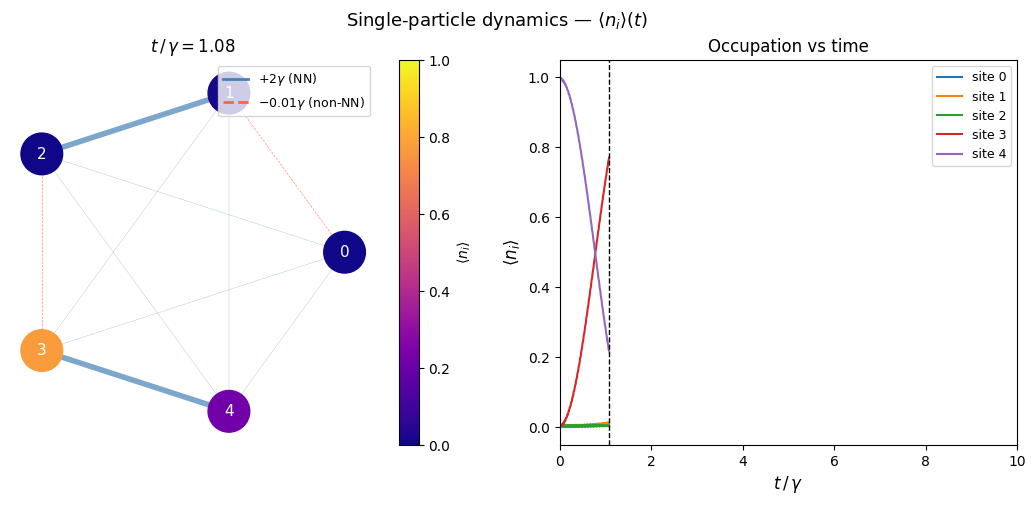

In [129]:
import matplotlib.animation as animation
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

# ── 1. Time evolution: collect n_i(t) ────────────────────────────────────────
psi = np.zeros(basis.shape[0], dtype=complex)
psi[1] = 1.0  # particle at site 0: |10000⟩

total_hamiltonian_scipy = total_hamiltonian.data.as_scipy()

time_simulated = np.linspace(0, 10 * gamma, int(50 * gamma))
delta_t = time_simulated[1] - time_simulated[0]

# n_data[frame, site] = <n_i>(t)
n_data = np.zeros((len(time_simulated), n_qubits))

for frame in range(len(time_simulated)):
    psi = expm_multiply(-1j * delta_t * total_hamiltonian_scipy, psi)
    prob = (psi.conj() * psi).real      # |ψ_s|², shape (2**n_qubits,)
    n_data[frame] = prob @ basis         # <n_i> = Σ_s |ψ_s|² * basis[s,i]

# ── 2. Build weighted graph (ZZ couplings as edge weights) ────────────────────
# Constraint term (+2γ) is present for ALL pairs.
# coupling_dict adds its contribution on top (×γ inside build_total_hamiltonian).
G_anim = nx.Graph()
G_anim.add_nodes_from(range(n_qubits))

edge_weights = {}
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        w = 2 * gamma                                          # constraint (all pairs)
        key = (i, j) if (i, j) in coupling_dict else \
              (j, i) if (j, i) in coupling_dict else None
        if key is not None:
            w += coupling_dict[key] * gamma                    # coupling_dict contribution
        G_anim.add_edge(i, j, weight=w)
        edge_weights[(i, j)] = w

pos_anim = nx.circular_layout(G_anim)

pos_edges = [(i, j) for (i, j), w in edge_weights.items() if w >= 0]
neg_edges = [(i, j) for (i, j), w in edge_weights.items() if w <  0]
max_w     = max(abs(w) for w in edge_weights.values()) or 1.0
pos_widths = [4 * abs(edge_weights[e]) / max_w for e in pos_edges]
neg_widths = [4 * abs(edge_weights[e]) / max_w for e in neg_edges]

# ── 3. Build figure ───────────────────────────────────────────────────────────
fig, (ax_g, ax_l) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(r"Single-particle dynamics — $\langle n_i \rangle(t)$", fontsize=13)

cmap = plt.cm.plasma
norm = Normalize(vmin=0, vmax=1)

# fixed edges (drawn once)
nx.draw_networkx_edges(G_anim, pos_anim, edgelist=pos_edges,
                       width=pos_widths, edge_color="steelblue",
                       alpha=0.7, ax=ax_g)
nx.draw_networkx_edges(G_anim, pos_anim, edgelist=neg_edges,
                       width=neg_widths, edge_color="tomato",
                       alpha=0.7, ax=ax_g, style="dashed")

# animated nodes
nodes = nx.draw_networkx_nodes(G_anim, pos_anim, ax=ax_g,
                                node_color=n_data[0], cmap=cmap,
                                vmin=0, vmax=1, node_size=900)
nx.draw_networkx_labels(G_anim, pos_anim, ax=ax_g,
                        font_color="white", font_size=11)
ax_g.axis("off")
plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax_g,
             label=r"$\langle n_i \rangle$")
ax_g.legend(handles=[
    Line2D([0], [0], color="steelblue", lw=2,
           label=rf"$+2\gamma$ (NN)"),
    Line2D([0], [0], color="tomato", lw=2, ls="--",
           label=rf"$-0.01\gamma$ (non-NN)"),
], loc="upper right", fontsize=9)

# time-series panel
t_over_gamma = time_simulated / gamma
ts_lines = [ax_l.plot([], [], label=f"site {i}")[0] for i in range(n_qubits)]
vline = ax_l.axvline(0, color="k", lw=1, ls="--")
ax_l.set_xlim(0, t_over_gamma[-1])
ax_l.set_ylim(-0.05, 1.05)
ax_l.set_xlabel(r"$t\,/\,\gamma$", fontsize=12)
ax_l.set_ylabel(r"$\langle n_i \rangle$", fontsize=12)
ax_l.legend(fontsize=9, loc="upper right")
ax_l.set_title("Occupation vs time")

# ── 4. Animation ──────────────────────────────────────────────────────────────
def init():
    nodes.set_array(n_data[0])
    for l in ts_lines:
        l.set_data([], [])
    return [nodes, vline] + ts_lines

def update(f):
    nodes.set_array(n_data[f])
    ax_g.set_title(rf"$t\,/\,\gamma = {t_over_gamma[f]:.2f}$")
    for i, l in enumerate(ts_lines):
        l.set_data(t_over_gamma[: f + 1], n_data[: f + 1, i])
    vline.set_xdata([t_over_gamma[f]])
    return [nodes, vline] + ts_lines

stride = max(1, len(time_simulated) // 300)   # keep ~300 frames in the video
ani = animation.FuncAnimation(
    fig, update,
    frames=range(0, len(time_simulated), stride),
    init_func=init, interval=30, blit=True,
)

ani.save("edge_state.mp4", writer="ffmpeg", fps=30, dpi=150)
print("Saved  →  dynamics_1d_chain.mp4")
plt.show()


#### Adiabatic State Preparation

We divide the initialization of the total hamiltonian, since the driver is just the 0-th component of the Z hamiltonian. We just need to tune the initialization of the other components

In [51]:
# get the total particle constrain 
gamma=50
ntot=1
links=np.zeros(n_qubits)
            
total_hamiltonian,longitudinal_hamiltonian,_=build_total_hamiltonian(n_qubits=n_qubits,d_opt=d_opt,gamma=gamma,links=links,coupling_dict=coupling_dict,ntot=ntot)

new_hamiltonian,_,hamiltonian_delta,_,_=build_effective_hamiltonian(total_hamiltonian=total_hamiltonian,basis=basis,gamma=gamma,low_energy_k=1,high_energy_k=[0,2])

links=new_hamiltonian.diagonal()*gamma

total_hamiltonian,longitudinal_hamiltonian,_=build_total_hamiltonian(n_qubits=n_qubits,d_opt=d_opt,gamma=gamma,links=links,coupling_dict=coupling_dict,ntot=ntot)


H_AA block:
<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 0 stored elements and shape (5, 5)>

H_RR diagonal: [ 50.+0.j  50.+0.j -65.+0.j  50.+0.j -65.+0.j -65.+0.j  50.+0.j -65.+0.j
 -65.+0.j -65.+0.j  50.+0.j]

Second-order correction (in units of 1/gamma):
<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 25 stored elements and shape (5, 5)>
  Coords	Values
  (0, 1)	(0.9999999999999999+0j)
  (0, 2)	(0.11538461538461528+0j)
  (0, 3)	(0.11538461538461528+0j)
  (0, 4)	(0.11538461538461528+0j)
  (0, 0)	(-0.15384615384615408+0j)
  (1, 0)	(0.9999999999999999+0j)
  (1, 2)	(0.9999999999999999+0j)
  (1, 3)	(0.11538461538461528+0j)
  (1, 4)	(0.11538461538461528+0j)
  (1, 1)	(0.7307692307692305+0j)
  (2, 0)	(0.11538461538461528+0j)
  (2, 1)	(0.9999999999999999+0j)
  (2, 3)	(0.9999999999999999+0j)
  (2, 4)	(0.11538461538461528+0j)
  (2, 2)	(0.7307692307692305+0j)
  (3, 0)	(0.11538461538461528+0j)
  (3, 1)	(0.11538461538461528+0j)
  (3, 2)	(0.9999999999999999+0j

Then the driver Hamiltonian

In [59]:
# get the total particle constrain 
ntot=1
# we define the effective longitudianl field that contributes to the driver hamiltonian hamiltonian of Be 6
external_field=np.zeros(diagonal_elements.shape[0])
external_field=-1/d_opt[0]**2
print(external_field,links)

_,driver_hamiltonian,_=build_total_hamiltonian(n_qubits=n_qubits,d_opt=d_opt,gamma=gamma,links=links+external_field,coupling_dict=coupling_dict,ntot=ntot)


print(driver_hamiltonian.diag())
print(basis)




-1.0 [ 0.15384615+0.j -0.73076923+0.j -0.73076923+0.j -0.73076923+0.j
  0.15384615+0.j]
[ 5.00000000e+01 -1.69230769e-02 -3.46153846e-02  4.99484615e+01
 -3.46153846e-02 -6.50515385e+01  4.99307692e+01  8.49138462e+01
 -3.46153846e-02 -6.50515385e+01 -6.50692308e+01 -3.00861538e+01
  4.99307692e+01 -3.00861538e+01  8.48961538e+01  1.04879231e+02
 -1.69230769e-02 -6.50338462e+01 -6.50515385e+01 -3.00684615e+01
 -6.50515385e+01 -1.45068462e+02 -3.00861538e+01 -1.01030769e+01
  4.99484615e+01 -3.00684615e+01 -3.00861538e+01 -1.01030769e+01
  8.49138462e+01 -1.01030769e+01  1.04879231e+02  1.09862308e+02]
[[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 0 1 1]
 [0 0 1 0 0]
 [0 0 1 0 1]
 [0 0 1 1 0]
 [0 0 1 1 1]
 [0 1 0 0 0]
 [0 1 0 0 1]
 [0 1 0 1 0]
 [0 1 0 1 1]
 [0 1 1 0 0]
 [0 1 1 0 1]
 [0 1 1 1 0]
 [0 1 1 1 1]
 [1 0 0 0 0]
 [1 0 0 0 1]
 [1 0 0 1 0]
 [1 0 0 1 1]
 [1 0 1 0 0]
 [1 0 1 0 1]
 [1 0 1 1 0]
 [1 0 1 1 1]
 [1 1 0 0 0]
 [1 1 0 0 1]
 [1 1 0 1 0]
 [1 1 0 1 1]
 [1 1 1 0 0]
 [1 1 1 0 1]
 

Then we get the state preparation, initializing the state and evolving the interpolate hamiltonian

(-0.03461538461538539+0j)


/home/ecosta/miniconda3/envs/annealing-nsm-env/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ecosta/miniconda3/envs/annealing-nsm-env/lib/python3.10/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


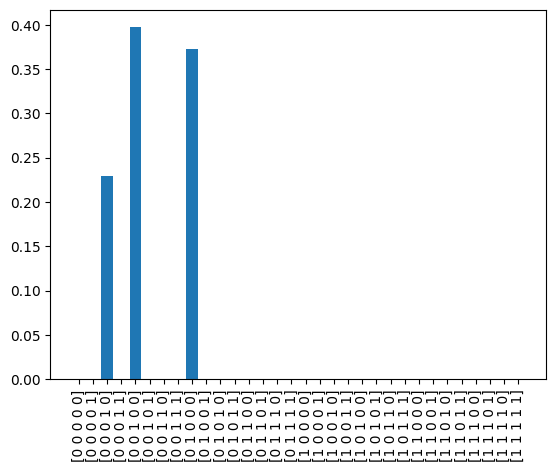

In [72]:
driver_hamiltonian_sparse=(driver_hamiltonian.data.as_scipy() )
_,psi=eigsh(driver_hamiltonian_sparse,k=25,which='SA')
psi=psi[:,17]

print(psi.conj().T @ driver_hamiltonian_sparse @ psi)
plt.bar(np.arange(basis.shape[0]),psi.conj()*psi)

plt.xticks(np.arange(basis.shape[0]),basis,rotation=90)
plt.show()

Time evolution

/home/ecosta/miniconda3/envs/annealing-nsm-env/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ecosta/miniconda3/envs/annealing-nsm-env/lib/python3.10/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


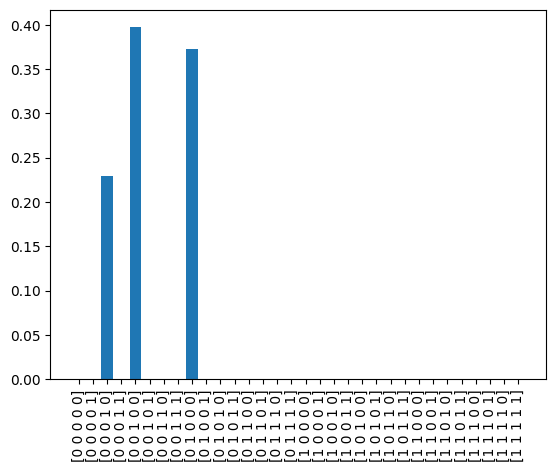

/tmp/ipykernel_122084/3890652646.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  energy[i]=psi.conj().dot(hamiltonian_t_sparse.dot( psi))


(-0.03461538461538539+0j)
final energy= (-0.0536957223789082+3.469446951953614e-18j)


In [73]:
#### Initialize the state and convert the hamiltonians
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply
total_hamiltonian_sparse=(total_hamiltonian.data.as_scipy())

plt.bar(np.arange(basis.shape[0]),psi.conj()*psi)
plt.xticks(np.arange(basis.shape[0]),basis,rotation=90)
plt.show()

print(psi.conj().T @ driver_hamiltonian_sparse @ psi)

#### start the time evolution

nlevels=20
tau=100
time_steps=int(10*tau)
time=np.linspace(0,tau,time_steps)
delta_t=time[1]-time[0]
spectrum=np.zeros((time_steps,nlevels))
energy=np.zeros(time_steps)
for i,t in enumerate(time):
    hamiltonian_t_sparse=(1-t/tau)*driver_hamiltonian_sparse+(t/tau)*total_hamiltonian_sparse
    psi=expm_multiply(-1j*delta_t*hamiltonian_t_sparse,psi)
    eigenvalues, eigenvectors = eigsh(hamiltonian_t_sparse, k=nlevels, which='SA')
    idx = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    spectrum[i] = eigenvalues
    energy[i]=psi.conj().dot(hamiltonian_t_sparse.dot( psi))  
print('final energy=',psi.conj().dot(total_hamiltonian_sparse.dot( psi)))


Results of the QA state preparation

/home/ecosta/miniconda3/envs/annealing-nsm-env/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ecosta/miniconda3/envs/annealing-nsm-env/lib/python3.10/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


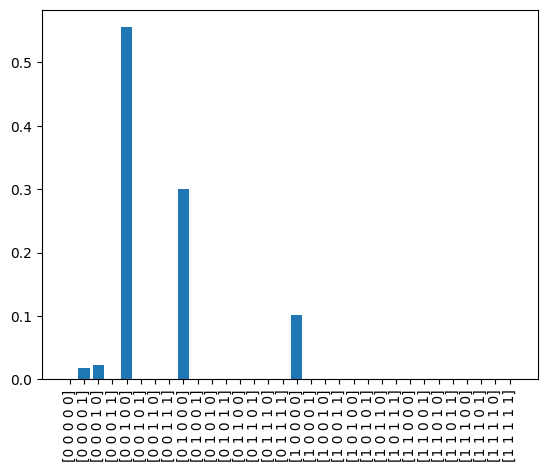

In [74]:
plt.bar(np.arange(basis.shape[0]),psi.conj()*psi)
plt.xticks(np.arange(basis.shape[0]),basis,rotation=90)
plt.show()

In [75]:
print(eigenvalues_total_hamiltonian)

[-2.90008848e+02 -1.30044564e+02 -1.30028837e+02 -1.30016654e+02
 -1.30008469e+02 -1.30001388e+02 -1.29992928e+02 -6.00283731e+01
 -6.00110313e+01 -5.99944093e+01 -5.99885852e+01 -5.99795105e+01
 -5.99777229e+01 -1.99732050e+01 -1.99661040e+01 -1.99339687e+01
 -1.96168812e-02 -7.68825163e-03  8.71675054e-04  1.00009158e-02
  1.64527502e-02  9.99966675e+01  1.00013063e+02  1.00015307e+02
  1.00017409e+02  1.00039205e+02  1.70007819e+02  1.70019163e+02
  1.70024220e+02  2.09962274e+02  2.10036585e+02  2.20124405e+02]


fidelity= 0.00046293588499126916 -2.732050807568869


/tmp/ipykernel_122084/1740044425.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)


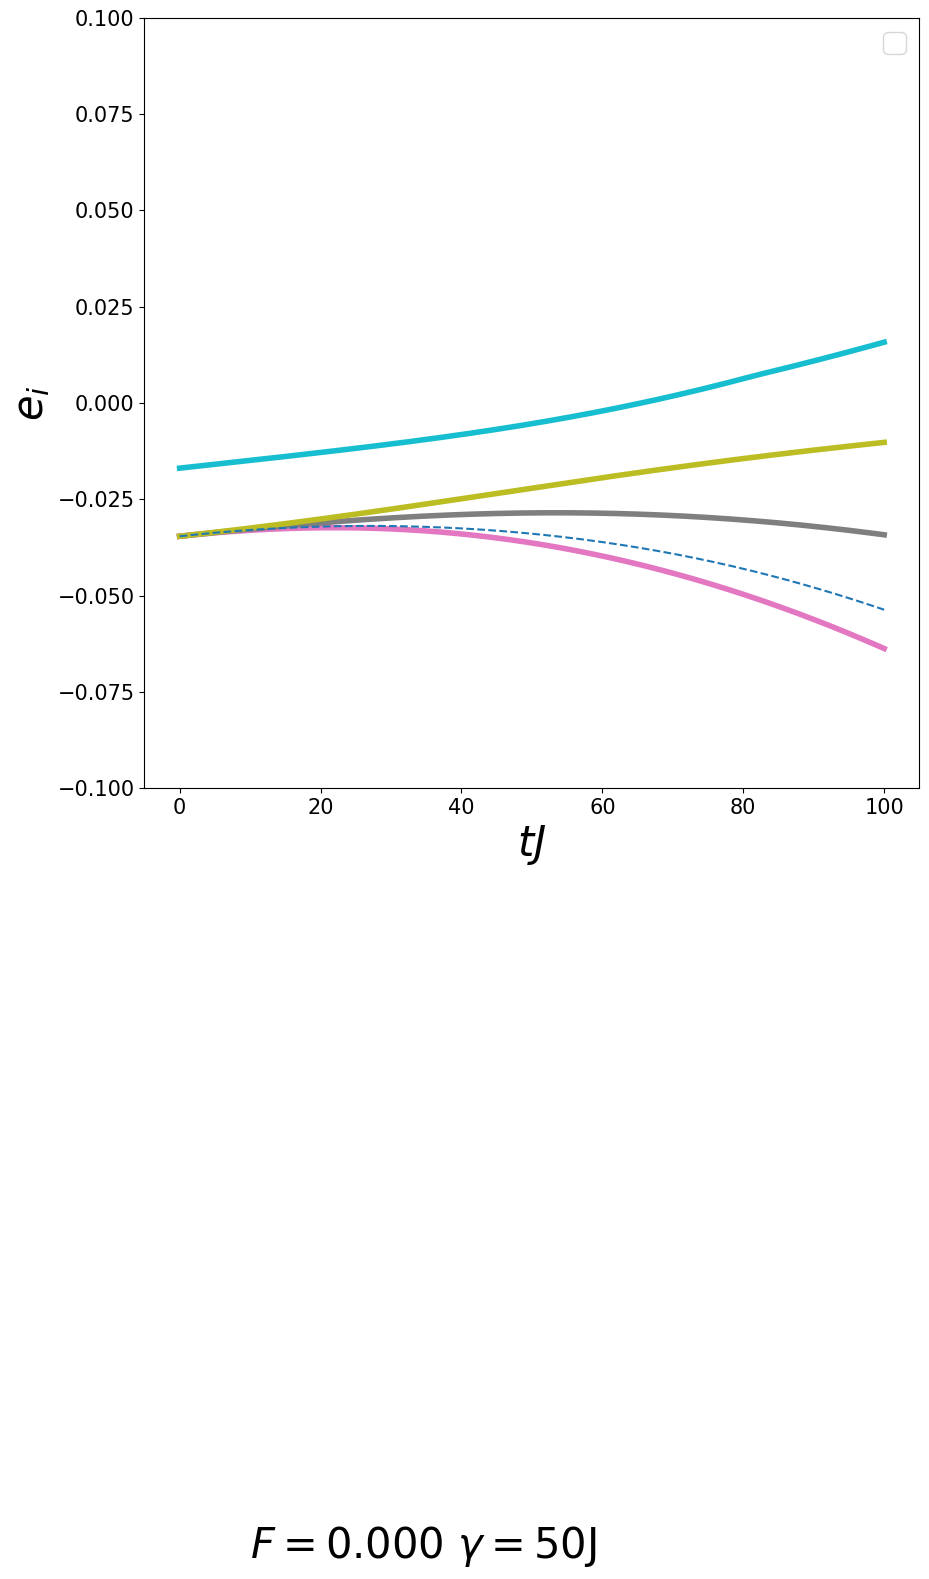

-2.68478611894541


In [80]:
plt.figure(figsize=(10,10))
plt.plot(time,spectrum,linewidth=4)
plt.plot(time,energy,linestyle='--')
psi_qutip=array_to_qutip(psi,n_qubits)
f_value=fidelity(psi_qutip,eigenstates_tb[0])
print('fidelity=',fidelity(psi_qutip,eigenstates_tb[0]),eigenvalues_tb[0])
plt.text(x=10,y=-0.3,s=r'$F=$'+f'{f_value:.3f} '+r'$\gamma=$'+f'{gamma:.0f}J',fontsize=30)
plt.xlabel(r'$tJ$',fontsize=30)
plt.ylabel(r'$e_i$',fontsize=30)
plt.legend(fontsize=20)
plt.ylim([-0.1,0.1])
plt.tick_params(which='major',labelsize=15)
plt.show()

print(energy[-1]*gamma)

#### Robstness of the Gadget vs $\gamma$

We study the robustness of the Gadget Hamiltonian tuning the $\gamma$ parameter, to check if we can reduce it to comparable values

In [132]:
from qutip import fidelity

gammas=np.linspace(1,200,40)
energy_error=[]
fidelities=[]
for gamma in gammas:
    # get the total particle constrain 
    ntot=1
    # we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
    effective_longitudinal_field=((d_opt**2))/(gamma)


    # lets start with the Z_A Z_B of the constrain
    hamiltonian_zz=0.
    for i in range(n_qubits):
        for j in range(i+1,n_qubits):
            hamiltonian_zz+=SpinOperator([('qz',i,'qz',j)],coupling=[2*gamma],size=n_qubits,verbose=1).qutip_op

    #### constrain related to the tunable effective energy
    hamiltonian_zz+=SpinOperator([('qz',0,'qz',2)],coupling=[-2*gamma],size=n_qubits,verbose=1).qutip_op
    hamiltonian_zz+=SpinOperator([('qz',1,'qz',3)],coupling=[-2*gamma],size=n_qubits,verbose=1).qutip_op


    # then the linear terms
    hamiltonian_z=0.
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        hamiltonian_z+=SpinOperator([('qz',i)],coupling=[effective_longitudinal_field[i]+gamma*(1-2*ntot)],size=n_qubits,verbose=1).qutip_op

    #finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
    identity_qubit_space=qt.tensor([qt.qeye(2)] * n_qubits)

    total_hamiltonian=hamiltonian_zz+hamiltonian_z+gamma*(ntot**2)*identity_qubit_space
    # the transverse field is part of the variable hamiltonian
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        total_hamiltonian+=SpinOperator([('x',i)],coupling=[d_opt[i]/(np.sqrt(2))],size=n_qubits,verbose=1).qutip_op

    eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = total_hamiltonian.eigenstates()
    print(eigenvalues_total_hamiltonian[2]*gamma,value[0],)
    energy_error.append(np.abs(eigenvalues_total_hamiltonian[2]*gamma-value[0])/np.abs(value[0]))
    print('fidelities=',qt.fidelity(
    eigenstates_total_hamiltonian[2],
    eigenstates_tb[gs_idx]),'\n')
    fidelities.append(qt.fidelity(
    eigenstates_total_hamiltonian[2],
    eigenstates_tb[gs_idx]
    ))

0.5505102572168239 -2.0
fidelities= 1.1379786002407855e-15 

-1.6362436515403618 -2.0
fidelities= 0.9414126569034271 

-1.8818206743385484 -2.0
fidelities= 0.9809996600212355 

-1.9429310997292262 -2.0
fidelities= 0.9908124404118263 

-1.9666007820809956 -2.0
fidelities= 0.9946192698143175 

-1.9781266380797544 -2.0
fidelities= 0.9964747946107195 

-1.984580699409994 -2.0
fidelities= 0.9975144078131799 

-1.9885516994223924 -2.0
fidelities= 0.998154274628344 

-1.991166394005699 -2.0
fidelities= 0.9985756890294191 

-1.992978432951541 -2.0
fidelities= 0.9988677837541857 

-1.9942854570294102 -2.0
fidelities= 0.9990784952451356 

-1.9952589867726969 -2.0
fidelities= 0.9992354554789344 

-1.9960034868998189 -2.0
fidelities= 0.9993554972358134 

-1.996585519962911 -2.0
fidelities= 0.9994493476743739 

-1.997049121190297 -2.0
fidelities= 0.9995241043391443 

-1.9974243620976138 -2.0
fidelities= 0.9995846145902332 

-1.9977323443874884 -2.0
fidelities= 0.9996342801679106 

-1.99798822834729

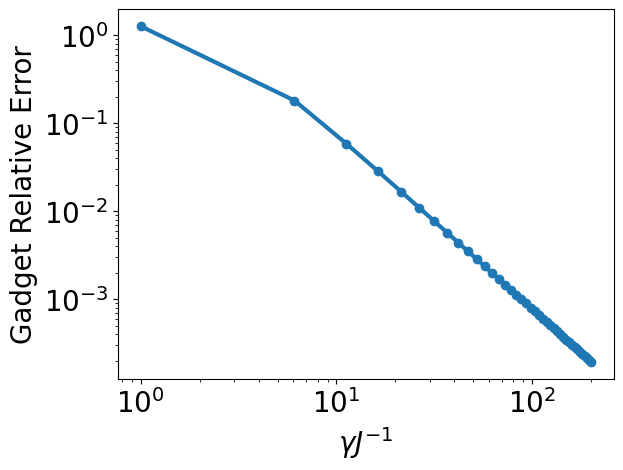

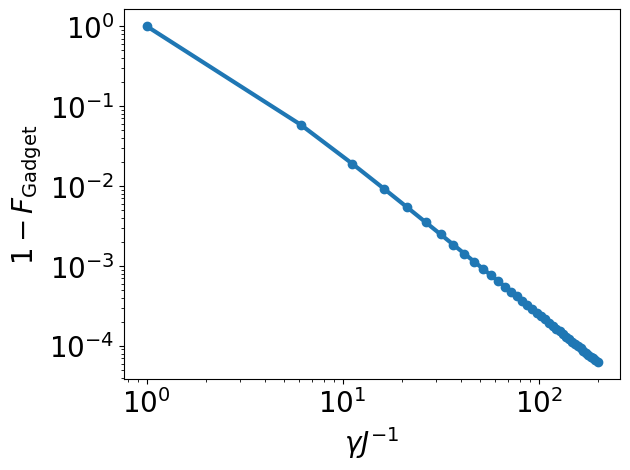

In [133]:
plt.plot(gammas,energy_error,linewidth=3,marker='o')
plt.xlabel(r'$\gamma J^{-1}$',fontsize=20)
plt.ylabel('Gadget Relative Error',fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

plt.plot(gammas,1-np.array(fidelities),linewidth=3,marker='o')
plt.xlabel(r'$\gamma J^{-1}$',fontsize=20)
plt.ylabel(r'$1-F_{\text{Gadget}}$',fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()



#### What about the state preparation using QA then ??

In [130]:
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply
fidelities=[]
energy_error=[]
gammas=np.linspace(1,50,10)
for gamma in gammas:
    # get the total particle constrain 
    ntot=1
    # we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
    effective_longitudinal_field=(diagonal_elements+0.5*(d_opt**2).sum())/(gamma)


    # lets start with the Z_A Z_B of the constrain
    hamiltonian_zz=0.
    for i in range(n_qubits):
        for j in range(i+1,n_qubits):
            hamiltonian_zz+=SpinOperator([('qz',i,'qz',j)],coupling=[2*gamma],size=n_qubits,verbose=1).qutip_op

    # then the linear terms
    hamiltonian_z=0.
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        hamiltonian_z+=SpinOperator([('qz',i)],coupling=[effective_longitudinal_field[i]+gamma*(1-2*ntot)],size=n_qubits,verbose=1).qutip_op

    #finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
    identity_qubit_space=qt.tensor([qt.qeye(2)] * n_qubits)

    total_hamiltonian=hamiltonian_zz+hamiltonian_z+gamma*(ntot**2)*identity_qubit_space
    # the transverse field is part of the variable hamiltonian
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        total_hamiltonian+=SpinOperator([('x',i)],coupling=[d_opt[i]/(np.sqrt(2))],size=n_qubits,verbose=1).qutip_op
    #### Initialize the state and convert the hamiltonians

    total_hamiltonian_sparse=(total_hamiltonian.data.as_scipy())
    driver_hamiltonian_sparse=(driver_hamiltonian.data.as_scipy() )
    #initialize the state
    psi=np.zeros(basis.shape[0])
    psi[idx_init]=1.



    #### start the time evolution

    nlevels=3
    tau=10*gamma
    time_steps=int(10*tau)
    time=np.linspace(0,tau,time_steps)
    delta_t=time[1]-time[0]
    spectrum=np.zeros((time_steps,nlevels))
    energy=np.zeros(time_steps)
    for i,t in enumerate(time):
        hamiltonian_t_sparse=(1-t/tau)*driver_hamiltonian_sparse+(t/tau)*total_hamiltonian_sparse
        psi=expm_multiply(-1j*delta_t*hamiltonian_t_sparse,psi)
        eigenvalues, eigenvectors = eigsh(hamiltonian_t_sparse, k=nlevels, which='SA')
        idx = np.argsort(eigenvalues)
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        spectrum[i] = eigenvalues
        energy[i]=psi.conj().dot(hamiltonian_t_sparse.dot( psi))
    psi_qutip=array_to_qutip(psi,n_qubits)
    energy_error.append(np.abs(energy[-1]*gamma-value[0])/np.abs(value[0]))
    f_value=fidelity(psi_qutip,eigenstates_total_hamiltonian[0])
    fidelities.append(f_value)
    print(gamma)
    print('energy=',energy[-1]*gamma)
    print('fidelity=',fidelity(psi_qutip,eigenstates_total_hamiltonian[0]))
    

/tmp/ipykernel_23341/3335997404.py:60: ComplexWarning: Casting complex values to real discards the imaginary part
  energy[i]=psi.conj().dot(hamiltonian_t_sparse.dot( psi))


1.0
energy= 2.616286067143038
fidelity= 0.31289911040216845
6.444444444444445
energy= 13.671967292646743
fidelity= 0.3178527935856509
11.88888888888889
energy= 36.558676385761856
fidelity= 0.36789444243760305
17.333333333333336
energy= 81.64573442066832
fidelity= 0.2920863086466979
22.77777777777778
energy= 142.87414265930084
fidelity= 0.31038942125424174


KeyboardInterrupt: 

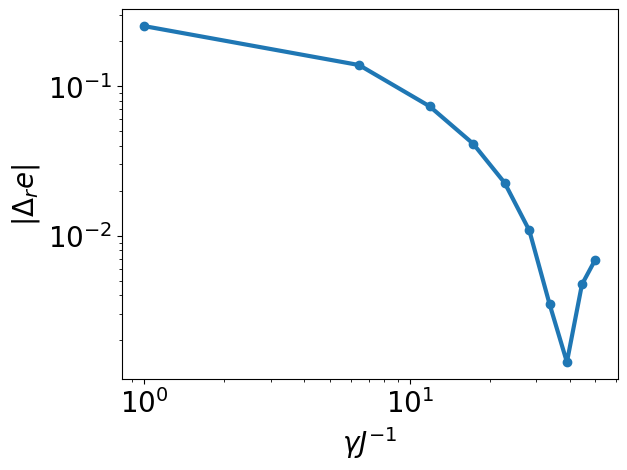

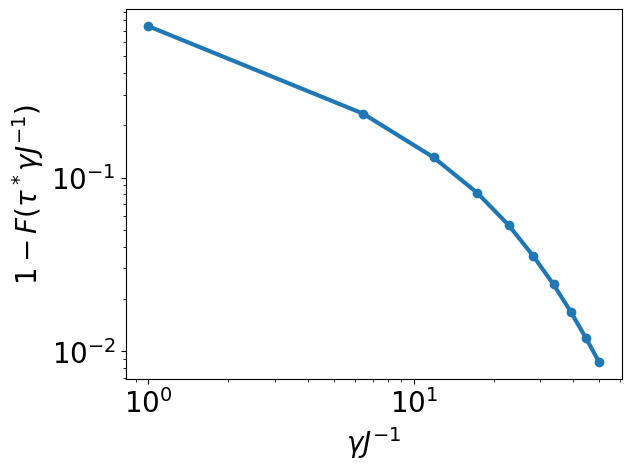

In [60]:
plt.plot(gammas,energy_error,linewidth=3,marker='o')
plt.xlabel(r'$\gamma J^{-1}$',fontsize=20)
plt.ylabel(r'$|\Delta_r e|$',fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

plt.plot(gammas,1-np.array(fidelities),linewidth=3,marker='o')
plt.xlabel(r'$\gamma J^{-1}$',fontsize=20)
plt.ylabel(r'$1-F(\tau^* \gamma J^{-1} )$',fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()
